### Imports

In [3]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import yaml
from pathlib import Path
import torch
from ultralytics import YOLO, settings


### Paths

In [5]:
DATASET_PATH = Path("../data/baseline.yaml")
OUTPUT_PATH = Path("../models/")
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

### Configure runs directory

In [7]:
new_runs_dir = OUTPUT_PATH  
settings.update({'runs_dir': str(new_runs_dir)})

### Device selection


In [9]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


### Load dataset configuration

In [11]:
with open(DATASET_PATH, 'r') as f:
    data_config = yaml.safe_load(f)
print(f"Number of classes: {data_config['nc']}")

Number of classes: 55


### Initialize model

In [13]:
model = YOLO("yolo11n.pt")

### Train the model


In [15]:
results = model.train(
    data=str(DATASET_PATH),      # Path to dataset YAML
    epochs=100,                   # Number of training epochs
    batch=-1,                     # Auto-batch size (optimizes GPU memory)
    imgsz=640,                    # Input image size
    device=device,                # GPU or CPU
    lr0=0.01,                     # Initial learning rate
    weight_decay=0.0005,          # L2 regularization
    momentum=0.937,               # SGD momentum
    workers=8,                    # Number of data loading workers
    patience=10,                  # Early stopping patience
    save=True,                    # Save checkpoints
    name="baseline_55class",      # Experiment name
    exist_ok=True,                # Overwrite existing folder
    verbose=True,                 # Print training logs
    seed=42                       # Random seed
)

print("Training completed!")

Ultralytics 8.4.41  Python-3.12.12 torch-2.2.0+cu118 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=..\data\baseline.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline_55class, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_m

### Evaluate on validation set

In [17]:
best_model_path = OUTPUT_PATH / "detect/baseline_55class/weights/best.pt"
best_model = YOLO(str(best_model_path))

val_results = best_model.val(
    data=str(DATASET_PATH),      # Dataset configuration
    batch=16,                     # Validation batch size
    imgsz=640,                    # Image size for validation
    device=device,                # GPU or CPU
    verbose=True,                 # Print validation results
    name='baseline_55class_val'
)



Ultralytics 8.4.41  Python-3.12.12 torch-2.2.0+cu118 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO11n summary (fused): 101 layers, 2,592,877 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 638.1273.2 MB/s, size: 53.1 KB)
val: Scanning C:\Users\isazo\OneDrive\Рабочий стол\courses\partfolio\pet_projects\traffic-sign-detection\data\raw\Traffic Signs\valid\labels.cache... 882 images, 43 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 882/882  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 56/56 4.3it/s 12.9s0.1s
                   all        882       1393      0.845      0.733      0.814      0.711
            forb_ahead         45         46      0.975      0.957      0.974      0.863
             forb_left         12         12      0.741      0.833       0.77       0.67
         forb_overtake         13         14      0.915          1       0.99      0.856
            forb_right

### Print validation metrics

In [19]:
print("\nValidation Results:")
print(f"mAP50-95: {val_results.box.map:.4f}")
print(f"mAP50: {val_results.box.map50:.4f}")
print(f"Precision: {val_results.box.mp:.4f}")
print(f"Recall: {val_results.box.mr:.4f}")

print(f"\nModel saved to: {OUTPUT_PATH}")


Validation Results:
mAP50-95: 0.7107
mAP50: 0.8136
Precision: 0.8448
Recall: 0.7328

Model saved to: ..\models


### Visualization

In [21]:
import sys
sys.path.append('../scripts')  
from visualization import *
%matplotlib inline

In [22]:
df = load_results("baseline_55class")

Loaded 71 epochs from baseline_55class


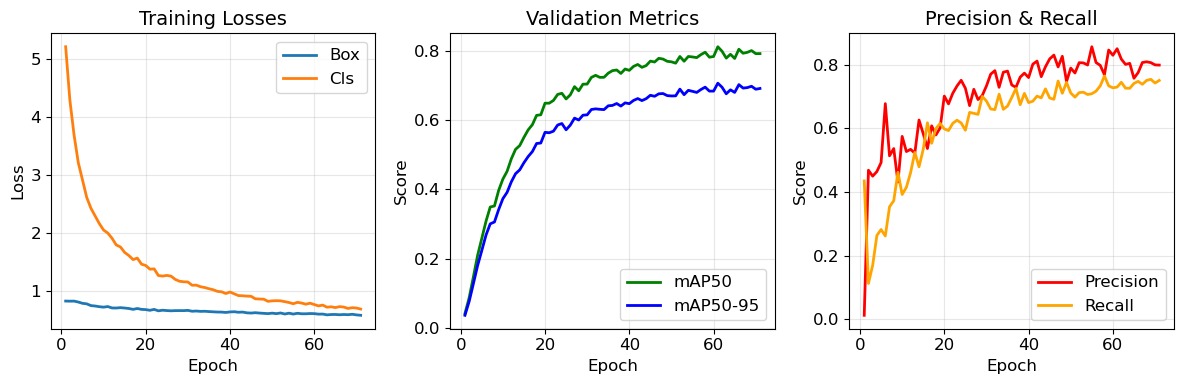

In [23]:
plot_losses(df)


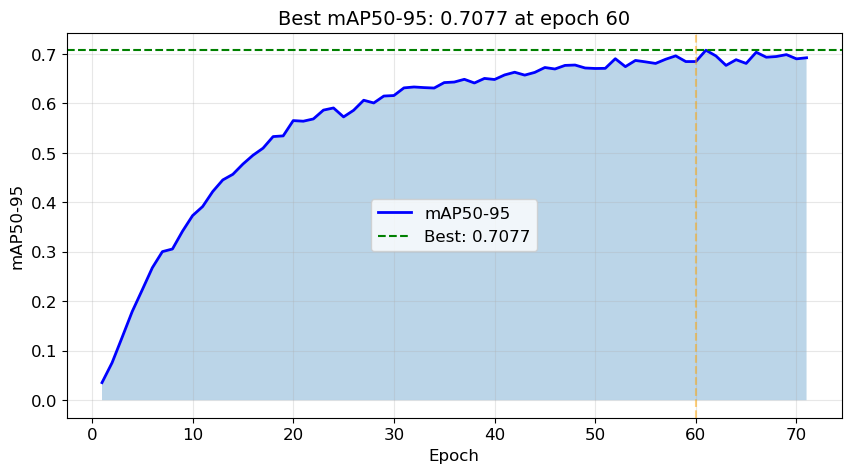

(60, 0.70769)

In [24]:
plot_map_progress(df)


In [25]:
print_summary(df)



TRAINING SUMMARY
Best mAP50-95:  0.7077 (epoch 60)
Final mAP50-95: 0.6924
Best mAP50:     0.8132
Best Precision: 0.8572
Best Recall:    0.7654

 Good! Only 11 epochs after peak


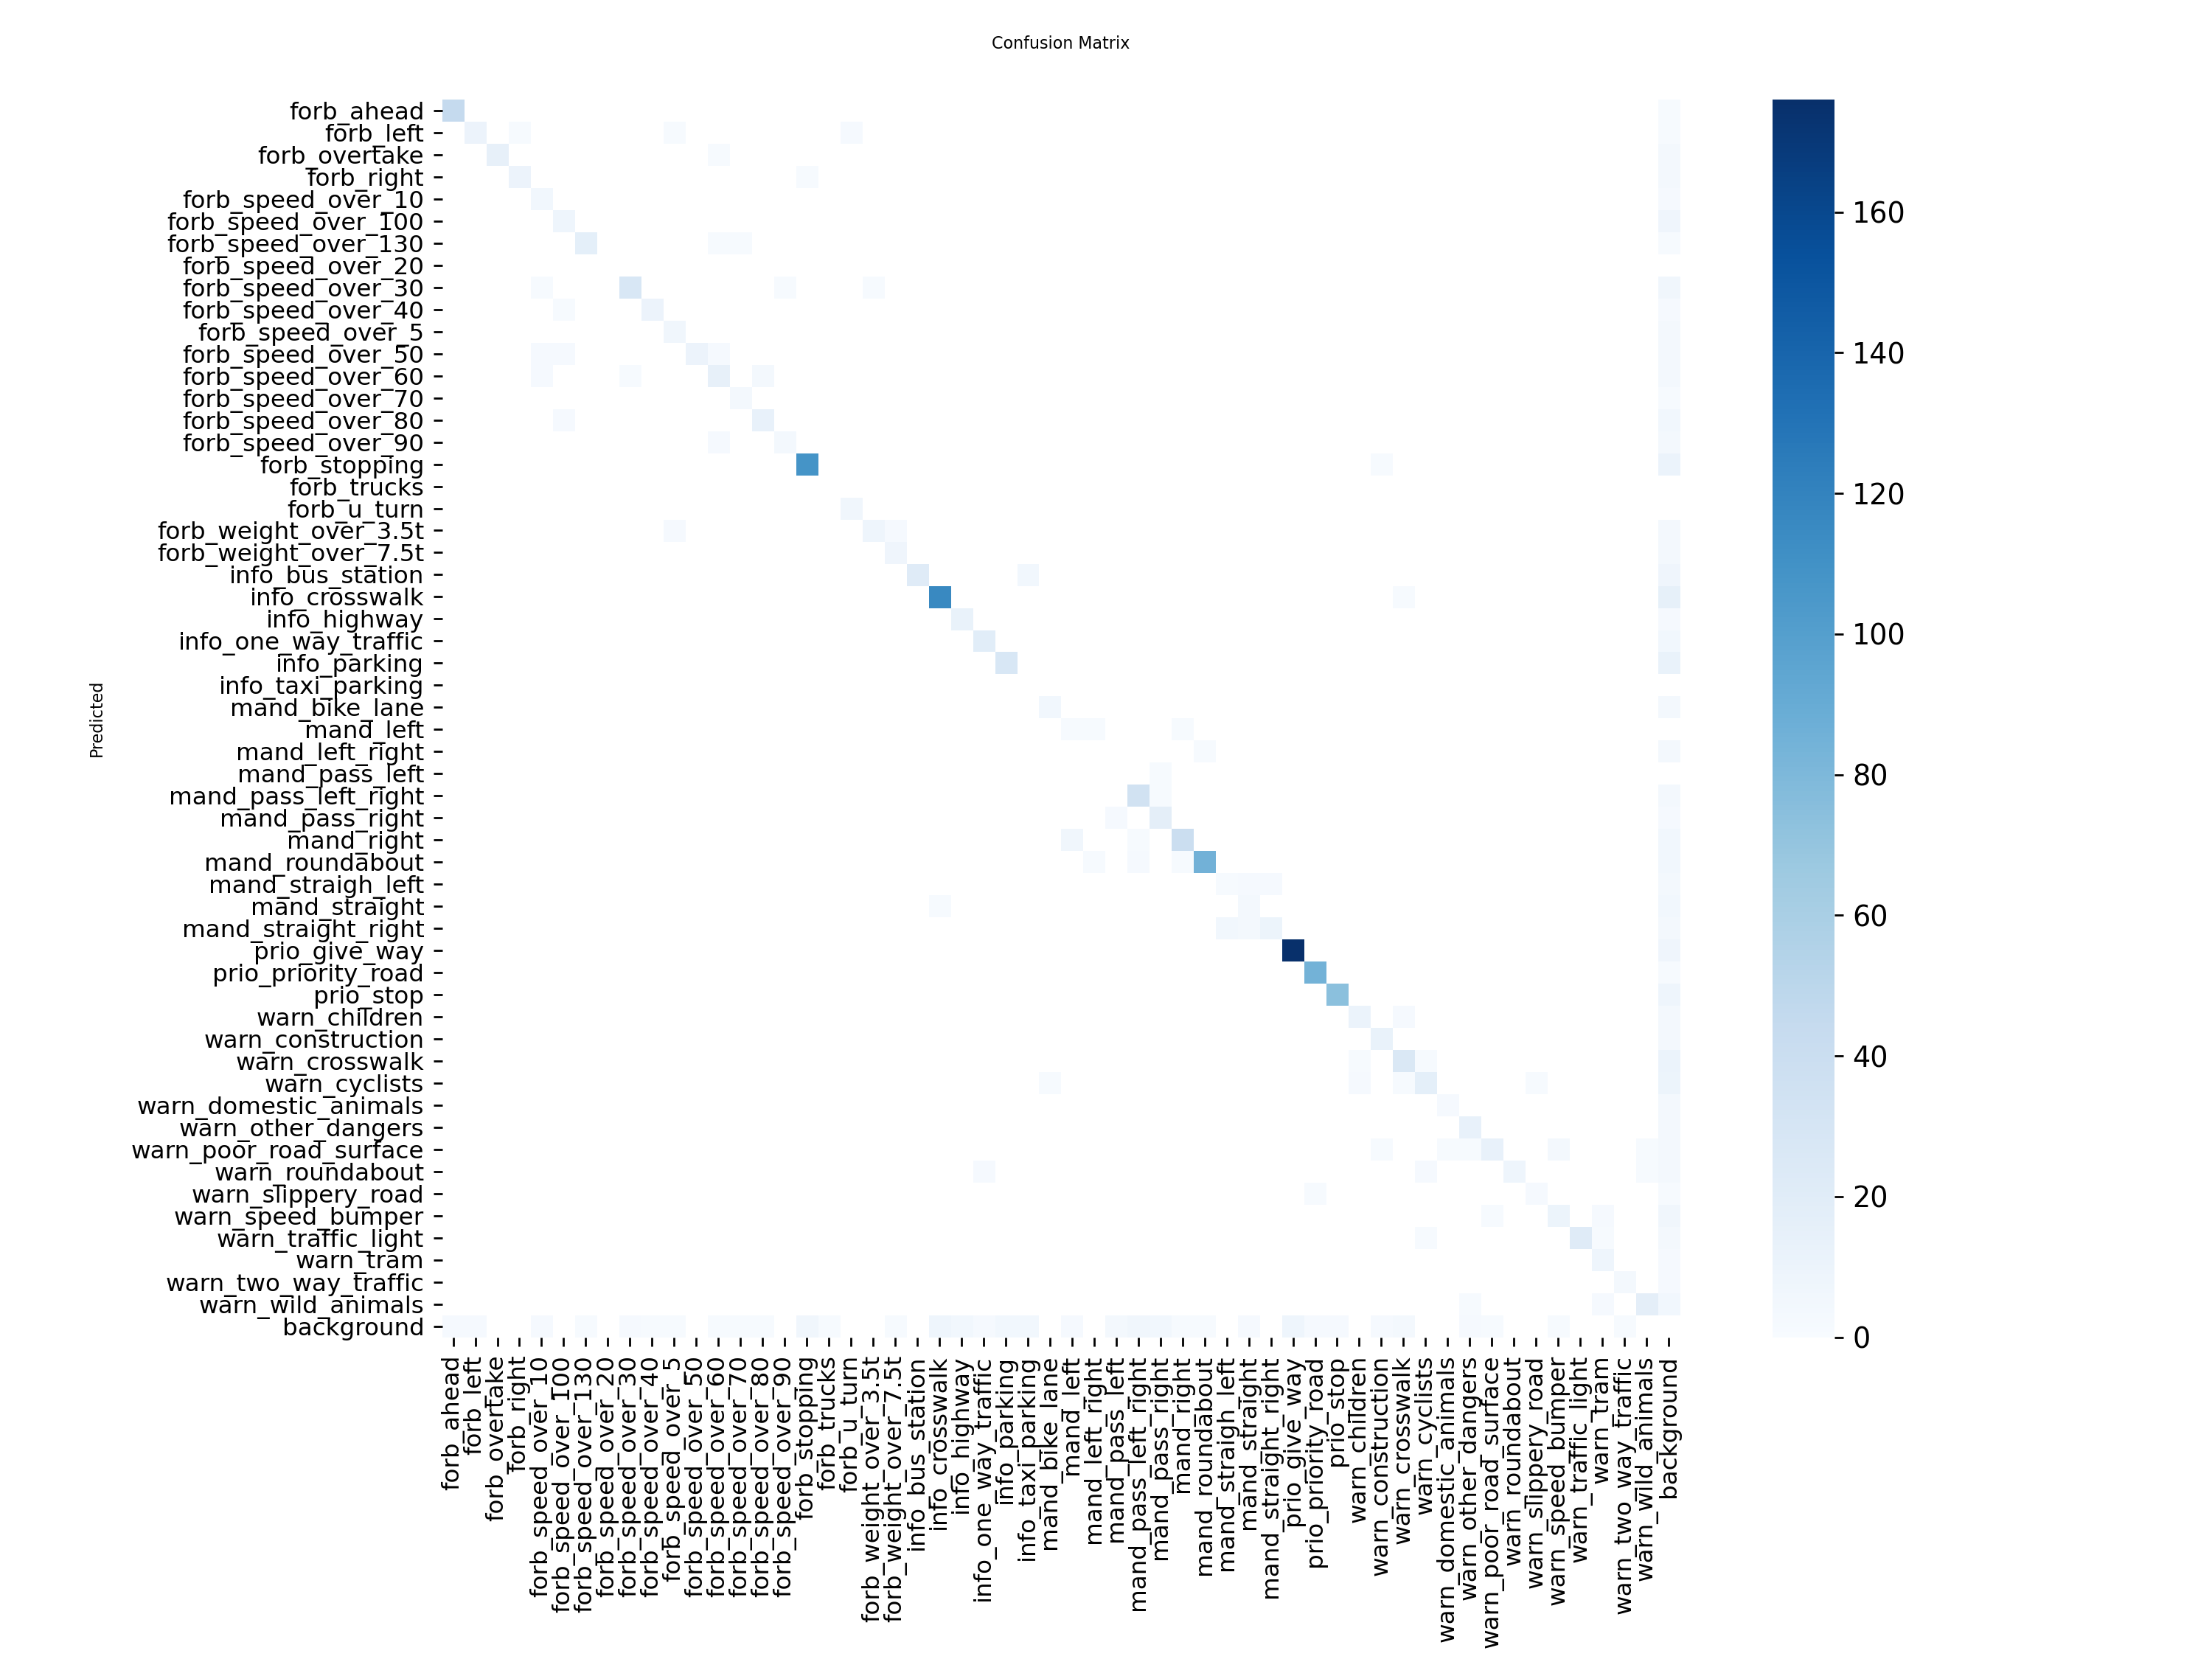

In [26]:
plot_confusion_matrix("baseline_55class")

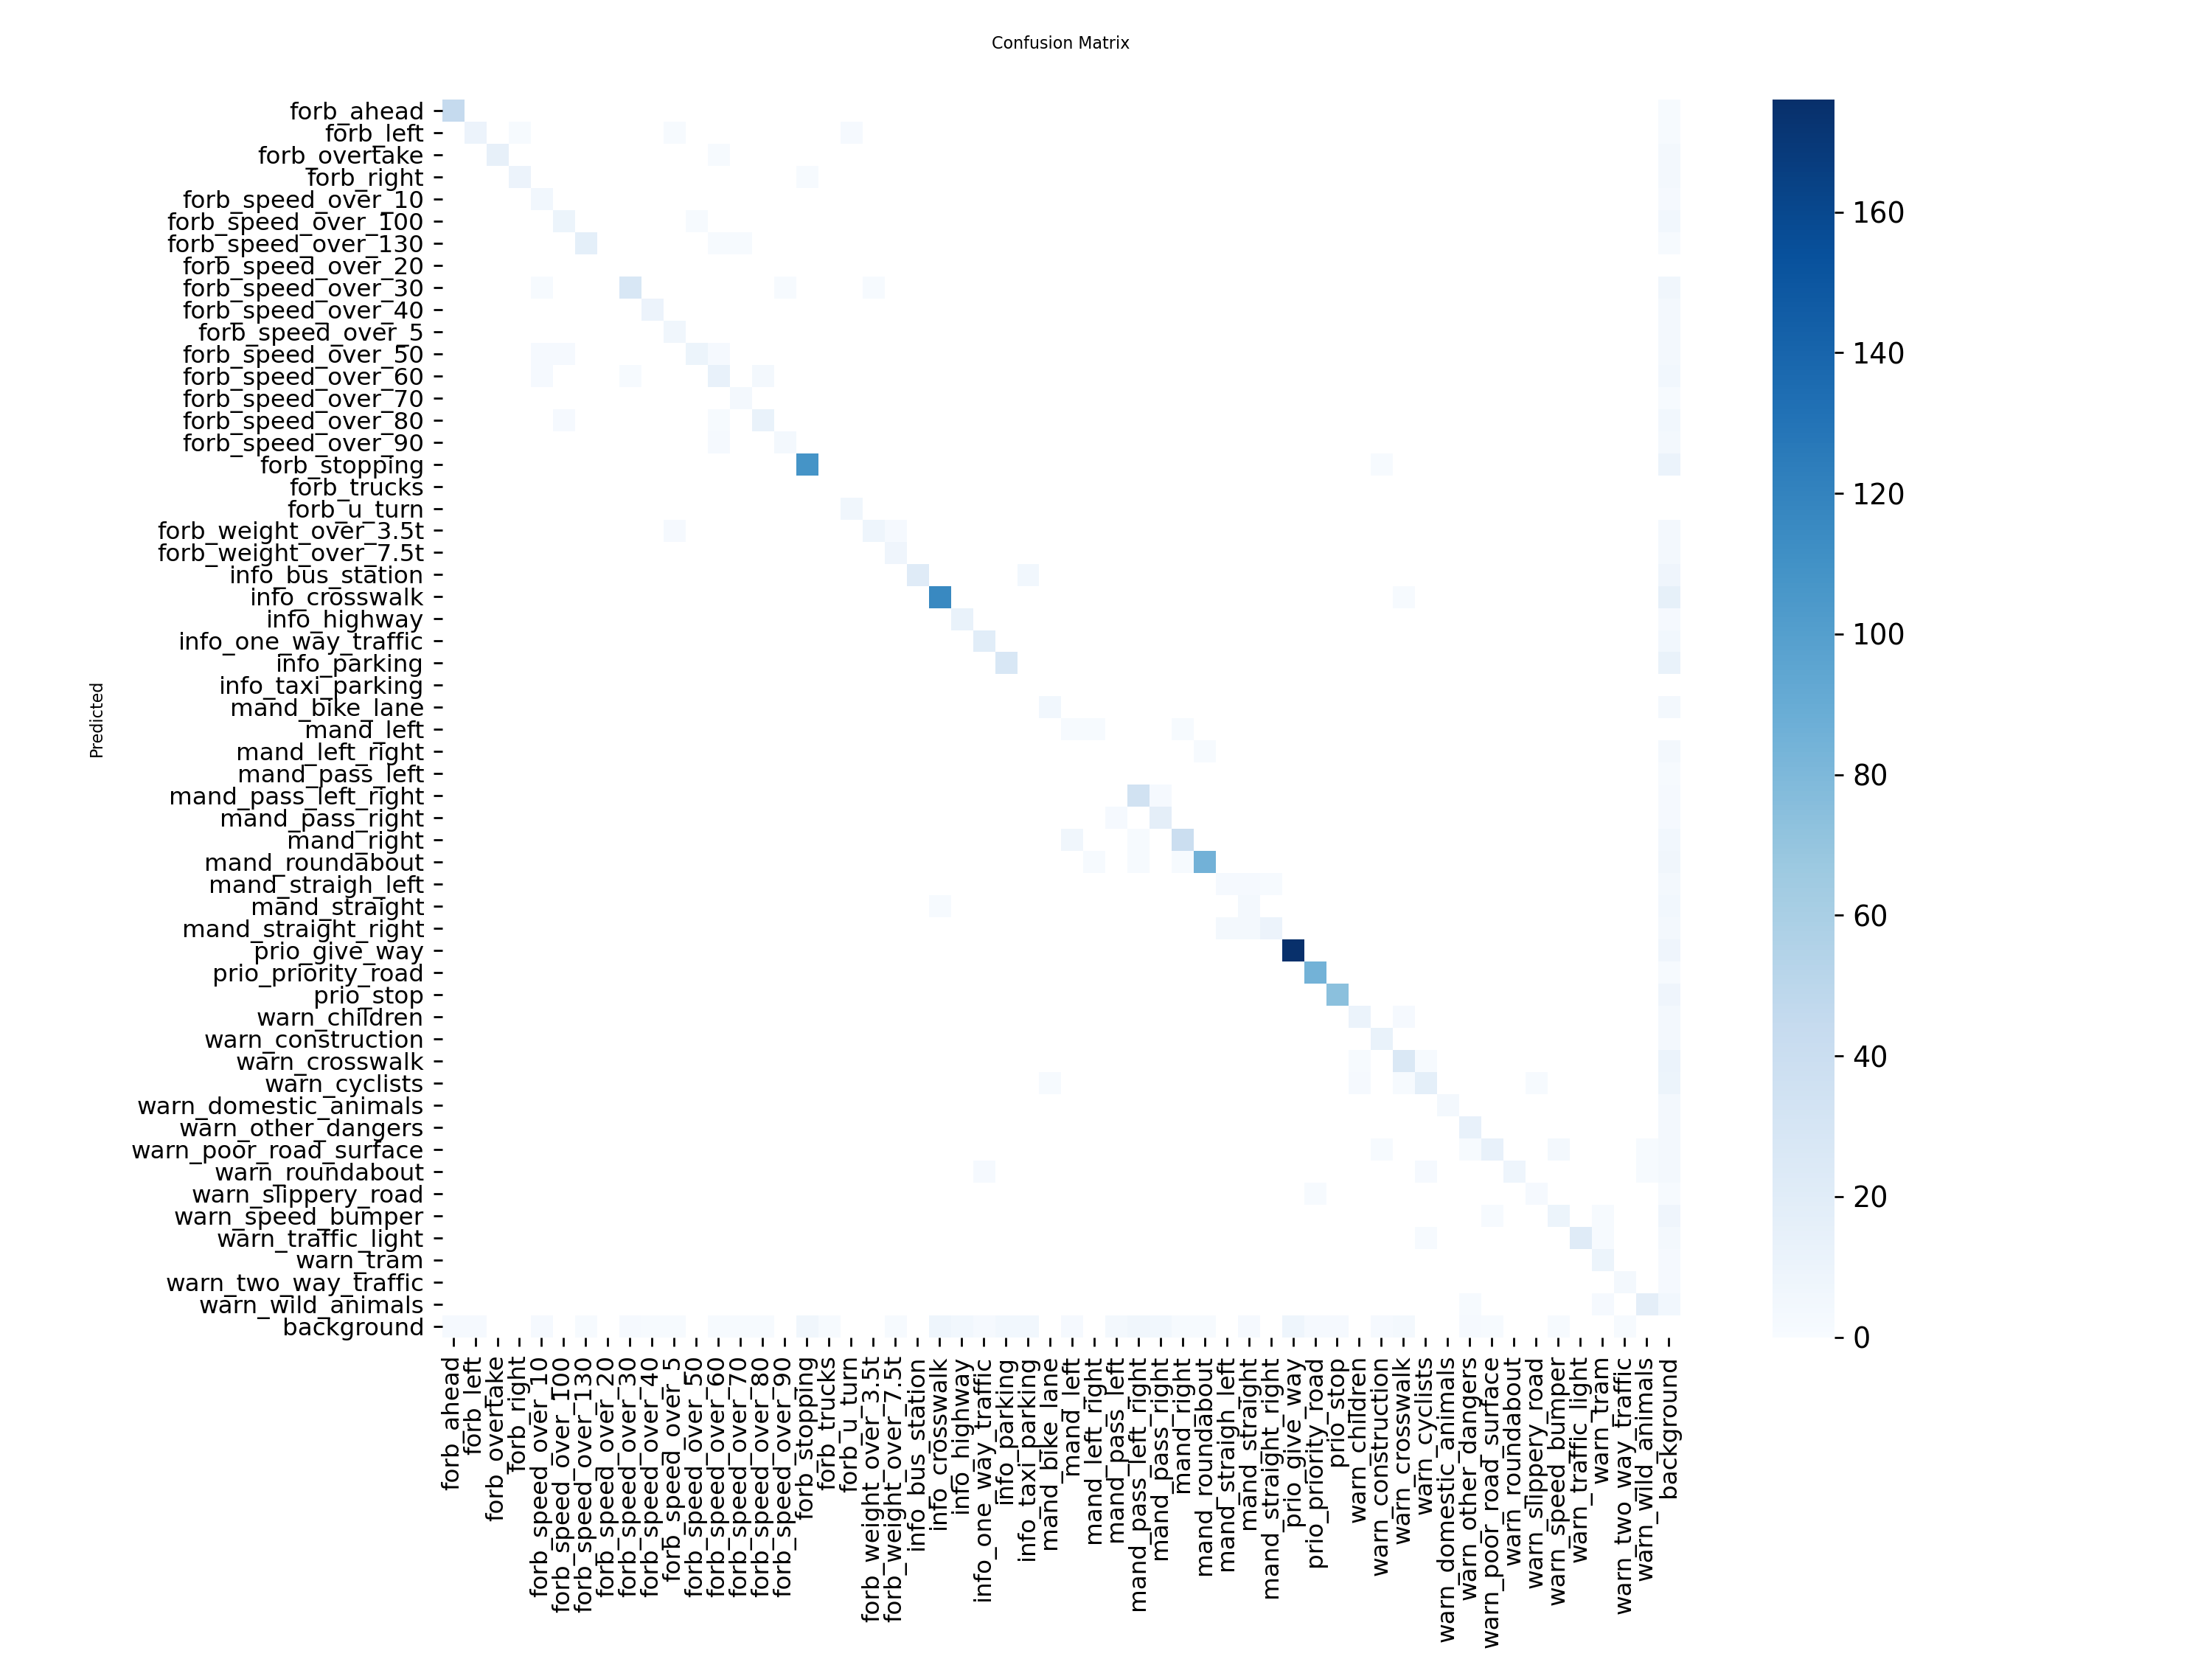

In [27]:
plot_confusion_matrix("baseline_55class_val")

# Final Summary & Conclusion: Traffic Sign Detection with YOLO11n

## 1. Training Overview
The YOLO11n model was trained to detect 55 classes of traffic signs. The training process was automatically stopped after **71 out of 100 epochs** due to the `patience=10` early stopping condition, as no improvement in the primary metric (`mAP50-95`) was seen for 10 consecutive epochs. The best performing model was saved from **epoch 61**.

## 2. Key Performance Metrics (Best Model at Epoch 61)

| Metric | Value |
| :--- | :--- |
| **mAP50-95** (Mean Average Precision @ 0.5:0.95 IoU) | **0.7077** |
| **mAP50** (Mean Average Precision @ 0.5 IoU) | **0.8132** |
| **Precision** | **0.8572** |
| **Recall** | **0.7654** |

## 3. Performance Analysis

### 3.1 Training Stability
- **Loss Curves:** The `box_loss`, `cls_loss`, and `dfl_loss` curves demonstrate a consistent and healthy downward trend, indicating stable and effective learning without significant overfitting or instability.
- **Metric Progression:** The `mAP50` and `mAP50-95` metrics show strong, rapid improvement followed by a stable plateau after approximately epoch 50, which is a sign of good model convergence.

### 3.2 Overall Model Performance
The final model achieves **high accuracy** in traffic sign detection.
- `mAP50` of **81.32%** shows that the model is very reliable at correctly identifying and localizing traffic signs.
- `mAP50-95` of **70.77%** indicates good localization precision across different IoU thresholds.

### 3.3 Class-wise Performance & Challenges
The per-class results reveal a common challenge in object detection: performance is heavily dependent on the number of training instances.

- **High-Performing Classes (with many examples):**
    - `prio_give_way` (181 instances) -> mAP50: 0.978
    - `prio_stop` (76 instances) -> mAP50: 0.986
    - `mand_roundabout` (87 instances) -> mAP50: 0.986
    - `forb_stopping` (115 instances) -> mAP50: 0.976

- **Low-Performing Classes (with few examples):**
    - `info_taxi_parking` (10 instances) -> mAP50: 0.126
    - `mand_left_right` (2 instances) -> mAP50: 0.0995
    - `mand_pass_left` (5 instances) -> mAP50: 0.151
    - `forb_trucks` (1 instance) -> mAP50: 0.995 (high precision, 0% recall)

This confirms that **class imbalance** and **insufficient data for rare classes** are the primary limiting factors for this model.

### 3.4 Early Stopping
Training stopped at epoch 71, which was only 11 epochs after the peak performance at epoch 61. This demonstrates that the `patience=10` setting was well-chosen, as it successfully prevented overfitting and saved significant computational resources.

## 4. Conclusion

The baseline YOLO11n model has been **successfully trained** and demonstrates **good to excellent performance** on the 55-class traffic sign detection task. The core metrics (mAP50 of 81.3% and mAP50-95 of 70.8%) validate its effectiveness and establish a strong foundation for this application.

